# TASK 3: HYPOTHESIS TESTING

---

## Objectives

Test statistical hypotheses to determine if relationships between variables are significant:

### Primary Research Question
**Does Gender significantly affect Workout Type selection?**

### Methodology
1. **Chi-square test of independence** - Test for association
2. **Effect size (Cramer's V)** - Measure strength of association
3. **Standardized residuals** - Identify specific patterns
4. **Post-hoc analysis** - Detailed interpretation

---

## Setup: Import Libraries

In [ ]:
!pip install pandas numpy matplotlib seaborn scipy scikit-learn dcor warnings

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical tests
from scipy import stats
from scipy.stats import chi2_contingency, chi2

# Configuration
import warnings
warnings.filterwarnings('ignore')

print("OK Libraries imported successfully")

OK Libraries imported successfully


## Visualization Configuration

In [18]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.0)

plt.rcParams.update({
    'figure.dpi': 100,
    'figure.figsize': (12, 8),
    'axes.titlesize': 14,
    'axes.labelsize': 11
})

print("OK Visualization configured")

OK Visualization configured


---

## Section 3.1: Data Loading and Preparation

Load data and verify from Task 2 distribution analysis.

In [19]:
# Load data
df = pd.read_csv('Life_style_data.csv')

print("="*80)
print("DATA LOADING")
print("="*80)
print(f"Dataset shape: {df.shape}")

# Create contingency table
contingency_table = pd.crosstab(df['Gender'], df['Workout_Type'])

print("\nContingency Table:")

display(contingency_table.style
        .set_caption("Observed Frequencies (Counts)")
        .background_gradient(cmap='YlGnBu', subset=pd.IndexSlice[:, :])
        .format('{:,.0f}')
        .set_properties(**{
            'text-align': 'center',
            'border': '1px solid black'
        }))

print(f"\nTotal observations: {contingency_table.sum().sum()}")



DATA LOADING
Dataset shape: (20000, 54)

Contingency Table:


Workout_Type,Cardio,HIIT,Strength,Yoga
Gender,,,,
Female,"2,418","2,479","2,601","2,530"
Male,"2,505","2,495","2,470","2,502"



Total observations: 20000


---

## Section 3.3: Chi-Square Test of Independence

CHI-SQUARE TEST OF INDEPENDENCE

TEST STATISTICS
--------------------------------------------------------------------------------
Chi-square statistic: 4.9721
Degrees of freedom (df): 3
p-value: 0.173849
Critical value (alpha = 0.05): 7.8147


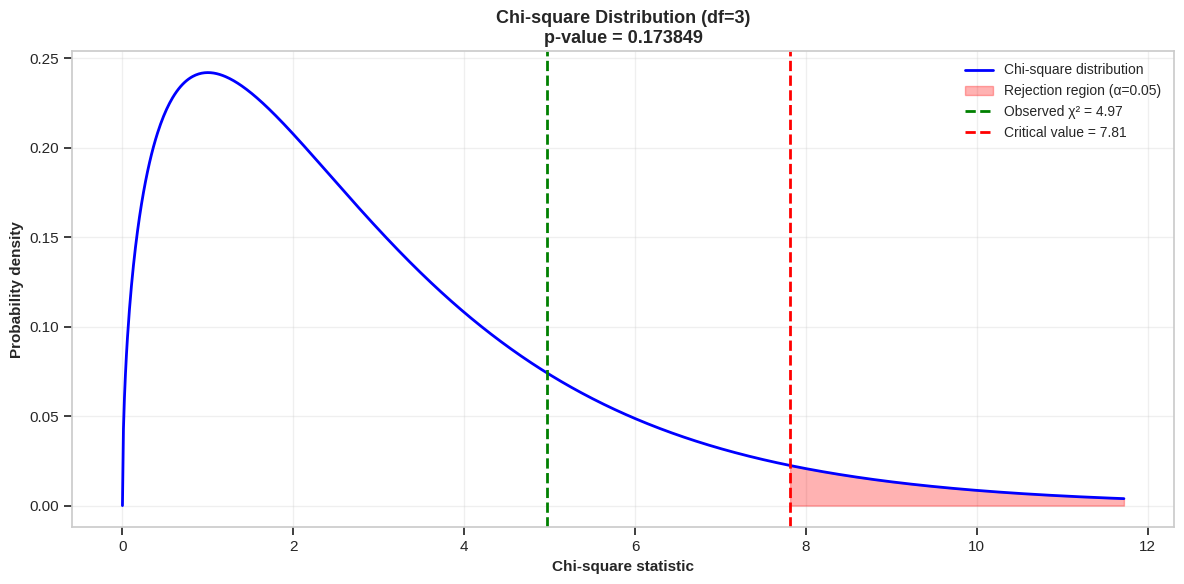

In [20]:
print("="*80)
print("CHI-SQUARE TEST OF INDEPENDENCE")
print("="*80)

# Perform chi-square test
chi2_stat, p_value, dof, expected_freq = chi2_contingency(contingency_table)

# Display results
print("\nTEST STATISTICS")
print("-"*80)
print(f"Chi-square statistic: {chi2_stat:.4f}")
print(f"Degrees of freedom (df): {dof}")
print(f"p-value: {p_value:.6f}")

# Critical value
alpha = 0.05
critical_value = chi2.ppf(1 - alpha, dof)
print(f"Critical value (alpha = 0.05): {critical_value:.4f}")

# Visualize chi-square distribution
fig, ax = plt.subplots(figsize=(12, 6))

x = np.linspace(0, max(chi2_stat * 1.5, critical_value * 1.5), 1000)
y = chi2.pdf(x, dof)

ax.plot(x, y, 'b-', linewidth=2, label='Chi-square distribution')
ax.fill_between(x[x >= critical_value], 0, chi2.pdf(x[x >= critical_value], dof),
                alpha=0.3, color='red', label=f'Rejection region (α={alpha})')
ax.axvline(chi2_stat, color='green', linestyle='--', linewidth=2,
           label=f'Observed χ² = {chi2_stat:.2f}')
ax.axvline(critical_value, color='red', linestyle='--', linewidth=2,
           label=f'Critical value = {critical_value:.2f}')

ax.set_xlabel('Chi-square statistic', fontweight='bold', fontsize=11)
ax.set_ylabel('Probability density', fontweight='bold', fontsize=11)
ax.set_title(f'Chi-square Distribution (df={dof})\np-value = {p_value:.6f}',
             fontweight='bold', fontsize=13)
ax.legend(loc='best', fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('Chi.png', dpi=300, bbox_inches='tight')
plt.show()

---

## Section 3.4: Effect Size - Cramer's V

EFFECT SIZE: CRAMER'S V
Cramer's V = 0.0158


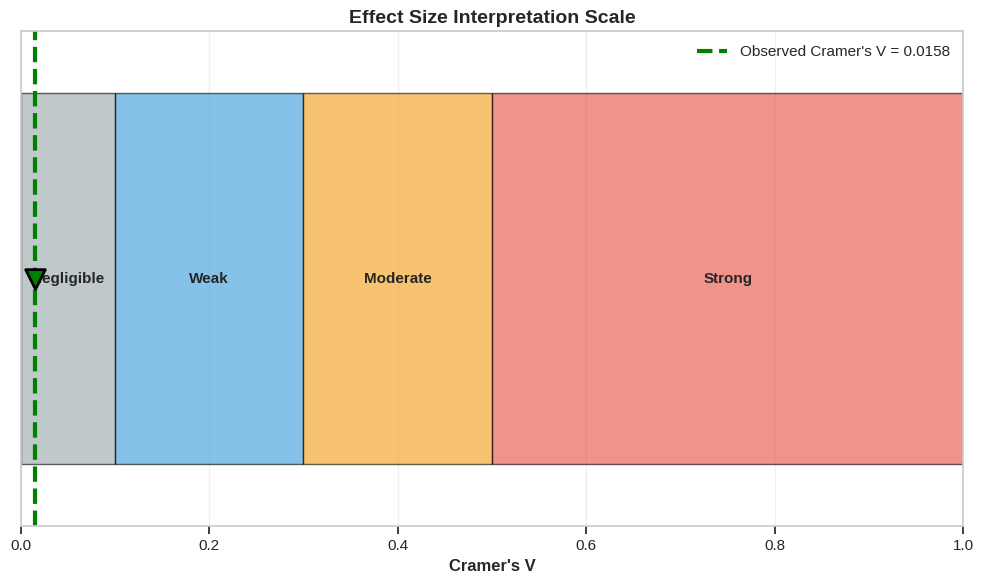

In [21]:
print("="*80)
print("EFFECT SIZE: CRAMER'S V")
print("="*80)

# Calculate Cramer's V
n = contingency_table.sum().sum()
k = min(contingency_table.shape)
cramers_v = np.sqrt(chi2_stat / (n * (k - 1)))
print(f"Cramer's V = {cramers_v:.4f}")

# Visualize effect size
fig, ax = plt.subplots(figsize=(10, 6))

# Create scale
scale_ranges = [0, 0.1, 0.3, 0.5, 1.0]
scale_labels = ['Negligible', 'Weak', 'Moderate', 'Strong']
scale_colors = ['#95a5a6', '#3498db', '#f39c12', '#e74c3c']

for i in range(len(scale_ranges) - 1):
    ax.barh(0, scale_ranges[i+1] - scale_ranges[i], left=scale_ranges[i],
            height=0.3, color=scale_colors[i], edgecolor='black', alpha=0.6)
    # Add label in center of bar
    center = (scale_ranges[i] + scale_ranges[i+1]) / 2
    ax.text(center, 0, scale_labels[i], ha='center', va='center',
            fontweight='bold', fontsize=11)

# Mark observed Cramer's V
ax.axvline(cramers_v, color='green', linestyle='--', linewidth=3,
           label=f"Observed Cramer's V = {cramers_v:.4f}")
ax.scatter([cramers_v], [0], s=200, color='green', marker='v',
           edgecolors='black', linewidths=2, zorder=5)

ax.set_xlim([0, 1])
ax.set_ylim([-0.2, 0.2])
ax.set_xlabel("Cramer's V", fontweight='bold', fontsize=12)
ax.set_title("Effect Size Interpretation Scale", fontweight='bold', fontsize=14)
ax.legend(loc='upper right', fontsize=11)
ax.set_yticks([])
ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('Cram.png', dpi=300, bbox_inches='tight')
plt.show()

## Section 3.5: Standardized Residuals Analysis

STANDARDIZED RESIDUALS ANALYSIS

1. OBSERVED FREQUENCIES
--------------------------------------------------------------------------------


Workout_Type,Cardio,HIIT,Strength,Yoga
Gender,,,,
Female,"2,418","2,479","2,601","2,530"
Male,"2,505","2,495","2,470","2,502"



2. EXPECTED FREQUENCIES (if independent)
--------------------------------------------------------------------------------


Workout_Type,Cardio,HIIT,Strength,Yoga
Gender,,,,
Female,"2,468.39","2,493.96","2,542.60","2,523.04"
Male,"2,454.61","2,480.04","2,528.40","2,508.96"



3. STANDARDIZED RESIDUALS
--------------------------------------------------------------------------------


Workout_Type,Cardio,HIIT,Strength,Yoga
Gender,,,,
Female,-1.014,-0.300,+1.158,+0.138
Male,+1.017,+0.300,-1.161,-0.139


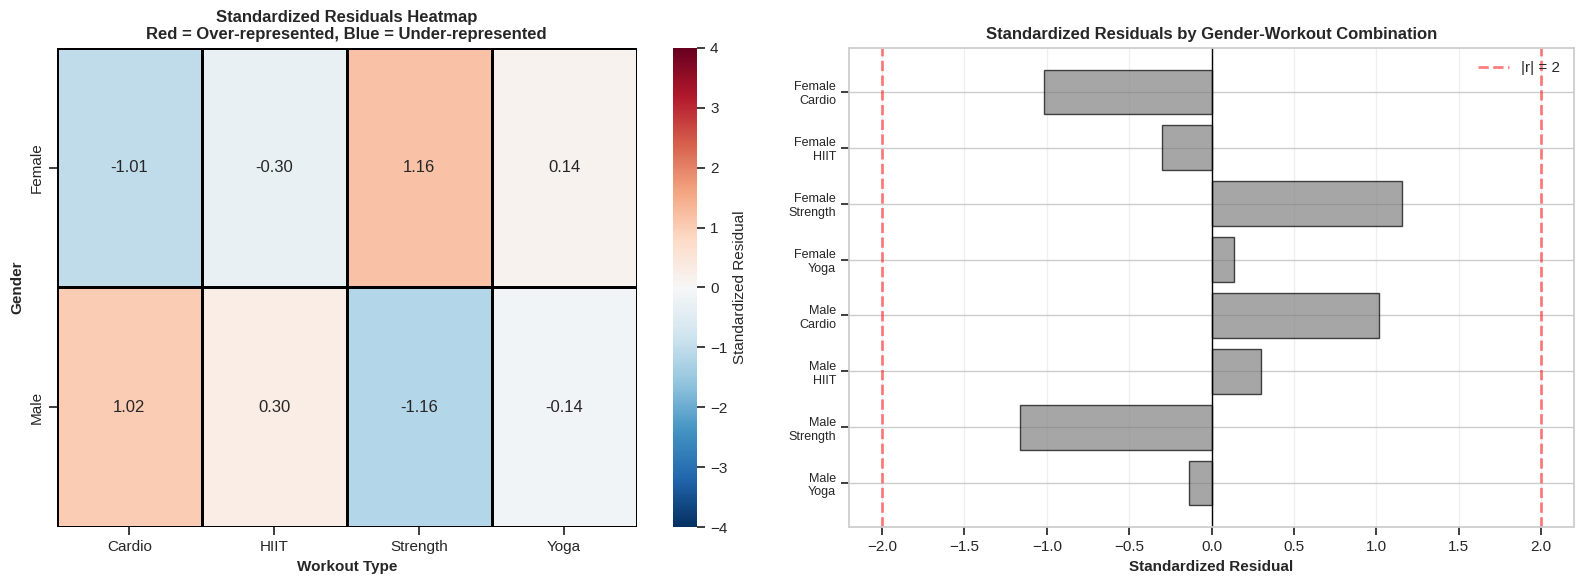

In [22]:
print("="*80)
print("STANDARDIZED RESIDUALS ANALYSIS")
print("="*80)

# Calculate standardized residuals
observed = contingency_table.values
expected = expected_freq

std_residuals = (observed - expected) / np.sqrt(expected)
std_residuals_df = pd.DataFrame(std_residuals,
                                index=contingency_table.index,
                                columns=contingency_table.columns)

print("\n1. OBSERVED FREQUENCIES")
print("-"*80)
display(contingency_table.style
        .set_caption("Observed Frequencies")
        .background_gradient(cmap='YlGnBu', subset=pd.IndexSlice[:, :])
        .format('{:,.0f}')
        .set_properties(**{
            'text-align': 'center',
            'border': '1px solid black'
        }))

print("\n2. EXPECTED FREQUENCIES (if independent)")
print("-"*80)
expected_df = pd.DataFrame(expected,
                          index=contingency_table.index,
                          columns=contingency_table.columns)
display(expected_df.style
        .set_caption("Expected Frequencies (if independent)")
        .background_gradient(cmap='YlGnBu', subset=pd.IndexSlice[:, :])
        .format('{:,.2f}')
        .set_properties(**{
            'text-align': 'center',
            'border': '1px solid black'
        }))

print("\n3. STANDARDIZED RESIDUALS")
print("-"*80)
display(std_residuals_df.style
        .set_caption("Standardized Residuals")
        .background_gradient(cmap='RdBu_r', vmin=-2, vmax=2) # Removed center=0
        .format('{:+.3f}')
        .set_properties(**{
            'text-align': 'center',
            'border': '1px solid black'
        }))

# Visualize residuals
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap of residuals
ax1 = axes[0]
sns.heatmap(std_residuals_df, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-4, vmax=4, ax=ax1,
            cbar_kws={'label': 'Standardized Residual'},
            linewidths=1, linecolor='black')
ax1.set_title('Standardized Residuals Heatmap\nRed = Over-represented, Blue = Under-represented',
              fontweight='bold', fontsize=12)
ax1.set_xlabel('Workout Type', fontweight='bold')
ax1.set_ylabel('Gender', fontweight='bold')

# Mark significant cells
for i in range(len(std_residuals_df.index)):
    for j in range(len(std_residuals_df.columns)):
        if abs(std_residuals_df.iloc[i, j]) > 2:
            ax1.add_patch(plt.Rectangle((j, i), 1, 1, fill=False,
                                       edgecolor='yellow', linewidth=3))
print("\n\n")
# Bar chart of residuals
ax2 = axes[1]
residuals_flat = std_residuals_df.values.flatten()
labels = [f"{g}\n{w}" for g in std_residuals_df.index
         for w in std_residuals_df.columns]

colors = ['red' if r > 2 else 'blue' if r < -2 else 'gray'
         for r in residuals_flat]
ax2.barh(range(len(residuals_flat)), residuals_flat, color=colors,
         edgecolor='black', alpha=0.7)
ax2.set_yticks(range(len(labels)))
ax2.set_yticklabels(labels, fontsize=9)
ax2.axvline(x=2, color='red', linestyle='--', linewidth=2, alpha=0.5, label='|r| = 2')
ax2.axvline(x=-2, color='red', linestyle='--', linewidth=2, alpha=0.5)
ax2.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax2.set_xlabel('Standardized Residual', fontweight='bold')
ax2.set_title('Standardized Residuals by Gender-Workout Combination',
              fontweight='bold', fontsize=12)
ax2.legend()
ax2.grid(alpha=0.3, axis='x')
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig('std.png', dpi=450, bbox_inches='tight')
plt.show()